Starting file parsing...
Successfully loaded records: 24
Detected columns: ['Size', 'Sequential', 'Parallel', 'Built-in']
Analysis complete. Plot saved as 'quicksort_regression_analysis.png'.


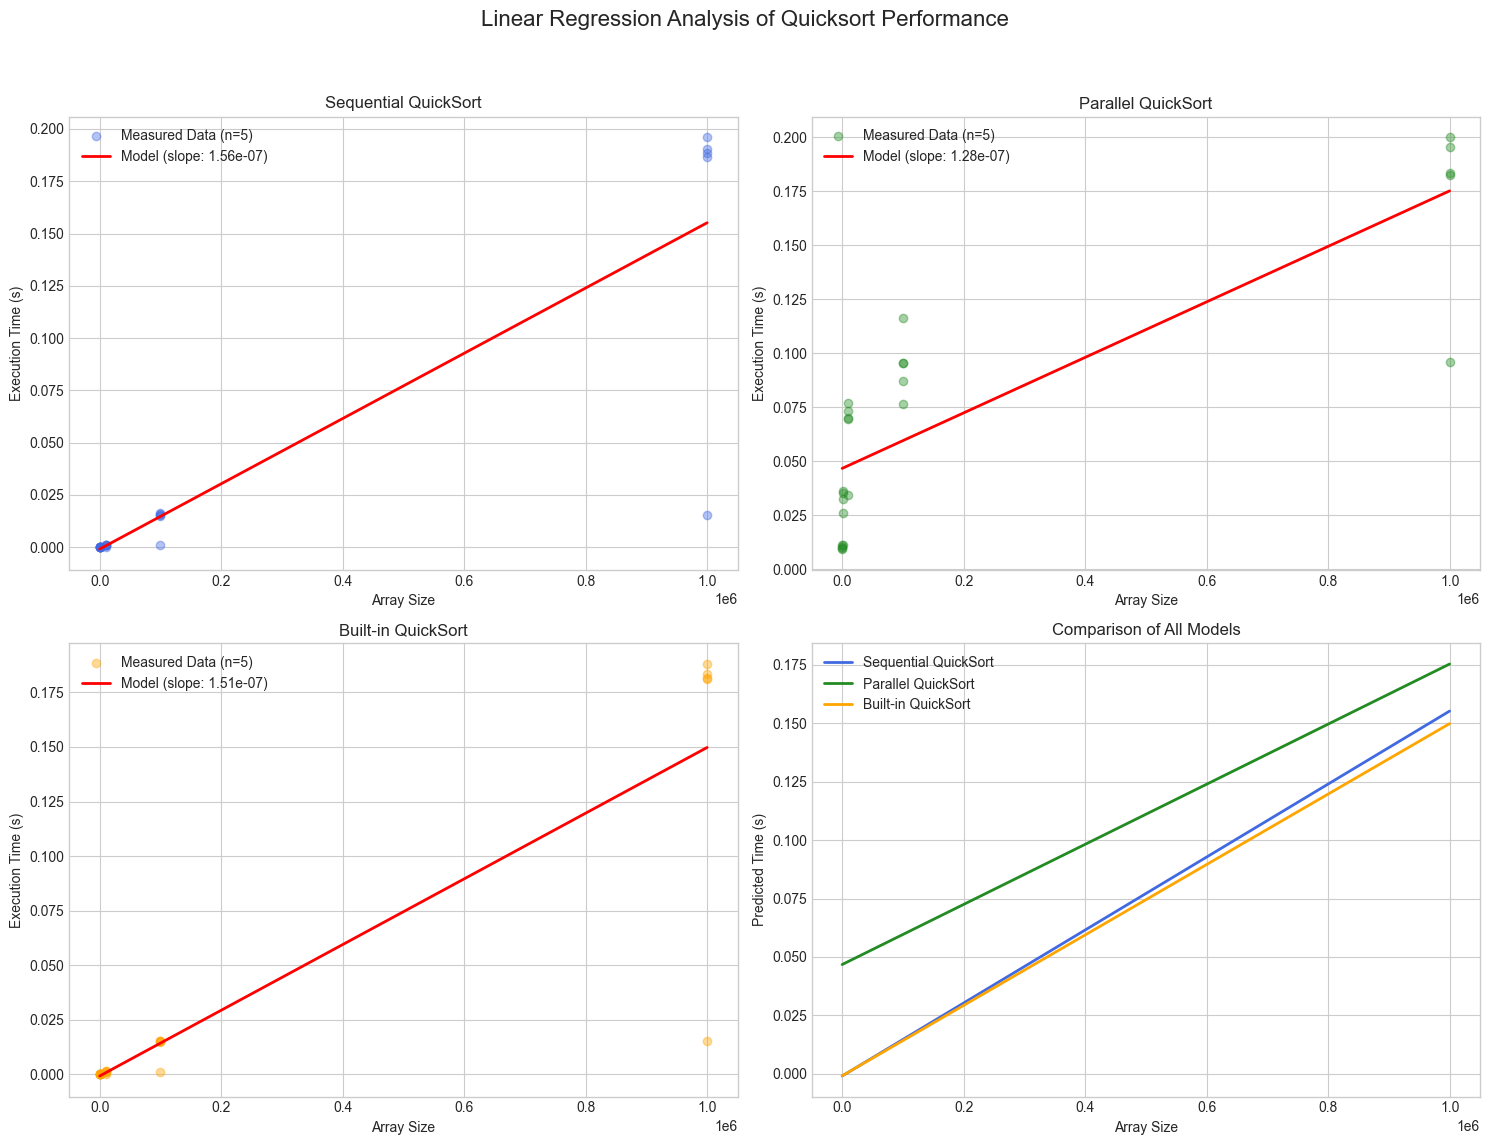

In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import re


file_path = r"C:\Users\dfomi\Desktop\SMPE-2025-2026-2\M2R ParallelQuicksort\scripts\data\vfomin_2025-11-06\measurements_1550.txt"

raw_data = []
current_record = {}

print("Starting file parsing...")

with open(file_path, "r", encoding="utf-8", errors="ignore") as f:
    for line_num, line in enumerate(f, 1):
        line = line.strip()
        if not line: continue
        
        # Searching for floating-point numbers (execution time)
        time_match = re.findall(r"(\d+\.\d+)", line)
        
        if "uential" in line.lower() and time_match:
            current_record["Sequential"] = float(time_match[0])
        elif "arallel" in line.lower() and time_match:
            current_record["Parallel"] = float(time_match[0])
        elif "uilt-in" in line.lower() and time_match:
            current_record["Built-in"] = float(time_match[0])
        
        # Searching for the array size (Size)
        size_match = re.search(r"Size[:\s]+(\d+)", line, re.IGNORECASE)
        if size_match:
            current_record["Size"] = int(size_match.group(1))
            # Once 'Size' is found, save the accumulated block data
            if all(k in current_record for k in ["Sequential", "Parallel", "Built-in", "Size"]):
                raw_data.append(current_record.copy())
                current_record = {}

# Create DataFrame
df = pd.DataFrame(raw_data)


if df.empty:
    print("!!! ERROR: No data found. Please check the file format or the path.")
    print("First 5 lines of the file for debugging:")
    try:
        with open(file_path, "r") as f:
            for _ in range(5):
                print(next(f).strip())
    except Exception as e:
        print(f"Could not read file: {e}")
else:
    print(f"Successfully loaded records: {len(df)}")
    print("Detected columns:", df.columns.tolist())


    df = df.dropna()

    # 2. Graph Plotting
    plt.style.use('seaborn-v0_8-whitegrid')
    fig, axs = plt.subplots(2, 2, figsize=(15, 12))
    fig.suptitle('Linear Regression Analysis of Quicksort Performance', fontsize=16)

    implementations = [
        ("Sequential", "Sequential QuickSort", "royalblue"),
        ("Parallel", "Parallel QuickSort", "forestgreen"),
        ("Built-in", "Built-in QuickSort", "orange")
    ]

    def plot_with_regression(ax, x, y, title, color):
        ax.scatter(x, y, color=color, alpha=0.4, label='Measured Data (n=5)')
        

        coef = np.polyfit(x, y, 1)
        poly = np.poly1d(coef)
        x_range = np.linspace(x.min(), x.max(), 100)
        
        ax.plot(x_range, poly(x_range), color='red', linewidth=2, label=f'Model (slope: {coef[0]:.2e})')
        ax.set_title(title)
        ax.set_xlabel('Array Size')
        ax.set_ylabel('Execution Time (s)')
        ax.legend()

    # Fill the first three subplots
    for i, (col, title, color) in enumerate(implementations):
        row, ax_idx = divmod(i, 2)
        plot_with_regression(axs[row, ax_idx], df["Size"], df[col], title, color)

    # 4th Plot: Comparison of all regression models
    ax_comp = axs[1, 1]
    for col, title, color in implementations:
        coef = np.polyfit(df["Size"], df[col], 1)
        poly = np.poly1d(coef)
        x_range = np.linspace(df["Size"].min(), df["Size"].max(), 100)
        ax_comp.plot(x_range, poly(x_range), label=title, color=color, linewidth=2)
    
    ax_comp.set_title("Comparison of All Models")
    ax_comp.set_xlabel('Array Size')
    ax_comp.set_ylabel('Predicted Time (s)')
    ax_comp.legend()

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig("quicksort_regression_analysis.png", dpi=300)
    print("Analysis complete. Plot saved as 'quicksort_regression_analysis.png'.")
    plt.show()